# Map Viz

This notebook will provide map visualization examples using popular viz packages. The topics cover:

- Choropleth map with data classification
- geoplot
- Legendgram
- Proportional symbol map
- Kernel density map
- contextily
- folium
- plotly

I will be using some previous florida data as examples.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = "https://raw.githubusercontent.com/Ziqi-Li/GIS5103/main/data/fl_income.geojson"
fl_income = gpd.read_file(path)

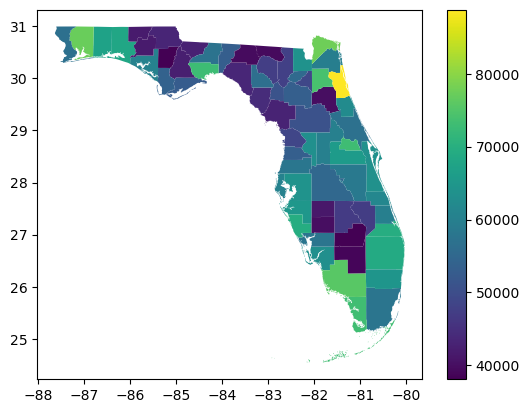

In [3]:
fl_income.plot("Median_income",legend=True)


#Save figure using .savefig, with a certain dpi
plt.savefig("Median_income_map.png", dpi=100)

## `mapclassify` for map data classification

Why Classify Data?: The primary reason to classify data is to simplify the data for visual display. For instance, if we assign a unique color to each county in FL based on its median income (referred to as an unclassed map) it is difficult to link a specific value with a specific color.

However, if we group the data values in some fashion (classify the data), it is easier to observe the data patterns.

In [4]:
#pip install mapclassify; or install using anaconda environment

In [5]:
import mapclassify

In [6]:
value = fl_income["Median_income"]

## Data classification methods

`mapclassify` supports popular classification methods.

| Method          | Strengths                                        | Weaknesses                                                       |
|-----------------|--------------------------------------------------|------------------------------------------------------------------|
| **Quantile**     | Equal number of items per class                  | Can result in unequal class ranges                               |
| **Equal Interval** | Simple to understand, emphasizes actual data ranges | Can produce unbalanced classes if data is skewed                 |
| **Natural Breaks** | Identifies clusters, meaningful class divisions   | Can result in uneven class sizes and computationally intensive    |
| **Fisher-Jenks**  | Optimized natural breaks, better variance minimization | Same weaknesses as Natural Breaks (uneven class sizes)            |


In [7]:
classifier = mapclassify.Quantiles(value, k=5)

#mapclassify.Quantiles(fl_income['Median_income'], k=5)
#mapclassify.EqualInterval(fl_income['Median_income'], k=5)
#mapclassify.FisherJenks(fl_income['Median_income'], k=5)
#mapclassify.NaturalBreaks(fl_income['Median_income'], k=5


# yb contains the bin IDs (or classes) for each classification
fl_income['income_class'] = classifier.yb



In [8]:
fl_income

,COUNTY,COUNTYNAME,Geo_ID,Name,Median_income,geometry,income_class
0,041,GILCHRIST,0500000US12041,"Gilchrist County, Florida",50983,"POLYGON ((-82.65814 29.83028, -82.65887 29.830...",1
1,107,PUTNAM,0500000US12107,"Putnam County, Florida",39975,"POLYGON ((-81.58084 29.83956, -81.60611 29.839...",0
2,123,TAYLOR,0500000US12123,"Taylor County, Florida",43563,"MULTIPOLYGON (((-83.73037 30.30358, -83.73987 ...",1
3,091,OKALOOSA,0500000US12091,"Okaloosa County, Florida",67390,"MULTIPOLYGON (((-86.39159 30.6497, -86.39157 3...",4
4,013,CALHOUN,0500000US12013,"Calhoun County, Florida",38098,"POLYGON ((-84.93266 30.60637, -84.95729 30.606...",0
...,...,...,...,...,...,...,...
62,033,ESCAMBIA,0500000US12033,"Escambia County, Florida",56605,"MULTIPOLYGON (((-87.23131 30.99697, -87.23756 ...",2
63,093,OKEECHOBEE,0500000US12093,"Okeechobee County, Florida",47020,"POLYGON ((-80.67932 27.55849, -80.67946 27.558...",1
64,037,FRANKLIN,0500000US12037,"Franklin County, Florida",52679,"MULTIPOLYGON (((-84.66713 30.01168, -84.70959 ...",1
65,001,ALACHUA,0500000US12001,"Alachua County, Florida",53314,"POLYGON ((-82.41869 29.92298, -82.41906 29.922...",2


In [9]:
import matplotlib.patches as mpatches

**Fix for the color issue to make sure legend colors match with map colors**

In [10]:
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=4)  # Assuming the class value ranges from 0 to 4 (5 classes)
normalized_value = norm(value)

#color map
cmap = plt.cm.OrRd

#to use cmap(value) to refer to the color given value.
#cmap()

Text(0.5, 1.0, 'Income Classification Using Quantiles')

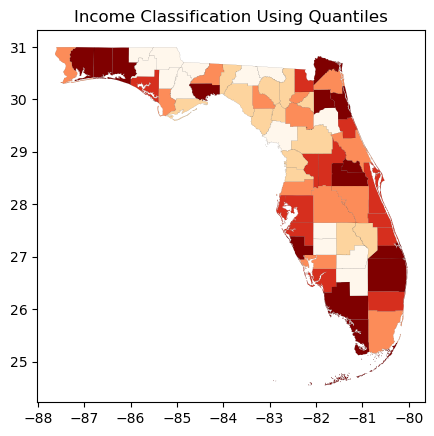

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

fl_income.plot(ax=ax, column='income_class', linewidth=0.05, cmap=cmap, edgecolor="black",legend=False)

plt.title(f'Income Classification Using Quantiles')

Text(0.5, 1.0, 'Income Classification Using Quantiles')

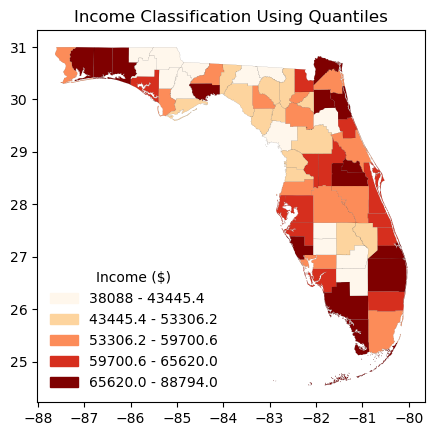

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

fl_income.plot(ax=ax, column='income_class', linewidth=0.05, cmap=cmap, edgecolor="black",legend=False)


legend_labels = [f"{round(lower, 2)} - {round(upper, 2)}" for lower, upper in zip([min(value)] + list(classifier.bins[:-1]), classifier.bins)]


#Create custom patches for the legend (one for each class)
patches = [mpatches.Patch(color=cmap(norm(i)), label=legend_labels[i]) for i in range(len(legend_labels))]

plt.legend(handles=patches, loc='lower left', title="Income ($)", frameon=False)

# Add title to the plot
plt.title(f'Income Classification Using Quantiles')



ChatGPT prompt: 

I am making a chropelth map of income for Florida, I have a geopandas GeoDataFrame named fl_income, and my income column is "Median_income", can you classify the values into 5 classes based on Quantile using mapclassify? Can you make the map with legend as patches.

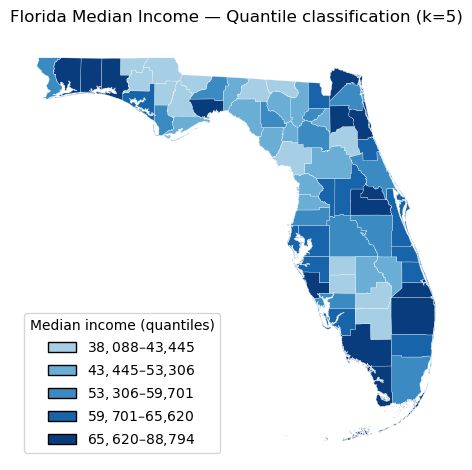

In [13]:
#Copied from ChatGPT response
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import mapclassify as mc

# 1) Classify into 5 quantile bins
classifier = mc.Quantiles(fl_income["Median_income"], k=5)

# 2) Build readable bin labels
data_min = float(np.nanmin(fl_income["Median_income"].values))
bins = classifier.bins  # length = 5 (upper edges)
lows = np.concatenate(([data_min], bins[:-1]))
highs = bins
labels = [f"${lo:,.0f}–${hi:,.0f}" for lo, hi in zip(lows, highs)]

# 3) Add class ids (0..4) to the GeoDataFrame
fl_income = fl_income.copy()
fl_income["_q5"] = classifier.yb  # integers 0..4; -1 for NaNs if any

# 4) Choose a simple sequential colormap with 5 steps
cmap = ListedColormap(plt.cm.Blues(np.linspace(0.35, 0.95, 5)))

# 5) Plot the choropleth (by class id) and add a patch legend
fig, ax = plt.subplots()
fl_income.plot(
    column="_q5",
    cmap=cmap,
    linewidth=0.2,
    edgecolor="white",
    vmin=0, vmax=4,
    legend=False,
    ax=ax
)

# Legend as colored patches
handles = [Patch(facecolor=cmap(i), edgecolor="black", label=labels[i]) for i in range(5)]
ax.legend(
    handles=handles,
    title="Median income (quantiles)",
    loc="lower left",
    frameon=True
)

ax.set_title("Florida Median Income — Quantile classification (k=5)", pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()


In [14]:
mapclassify.UserDefined(y=fl_income['Median_income'], bins=[40000, 60000, 80000])

UserDefined

      Interval         Count
----------------------------
[38088.00, 40000.00] |     7
(40000.00, 60000.00] |    34
(60000.00, 80000.00] |    25
(80000.00, 88794.00] |     1

Put all classification methods into one single map

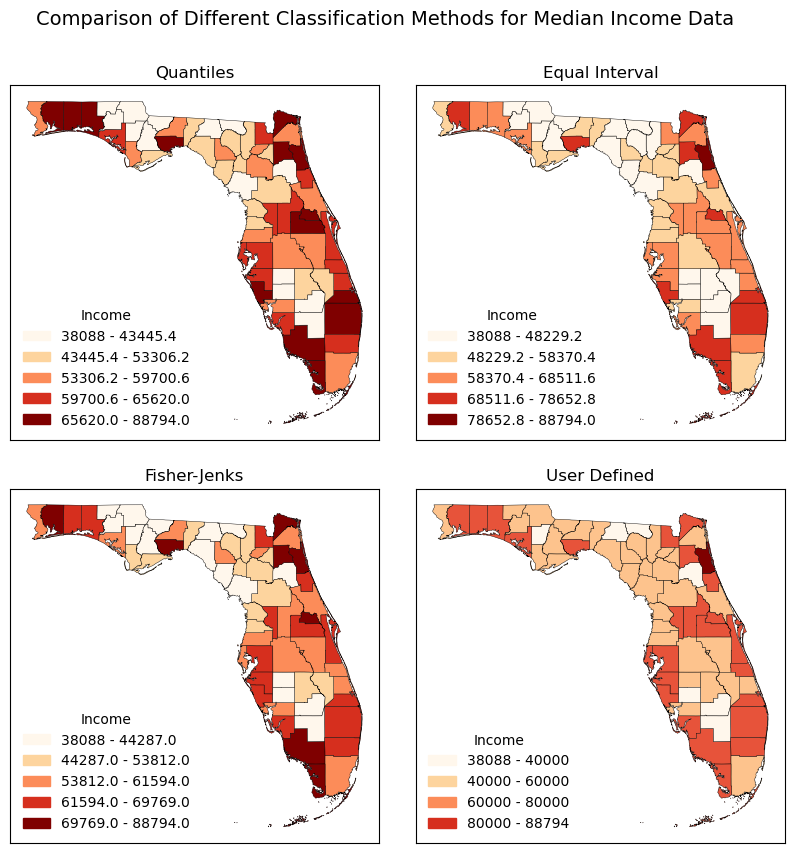

In [15]:
# Define different classification methods we want to compare
classifiers = {
    "Quantiles": mapclassify.Quantiles(fl_income['Median_income'], k=5),
    "Equal Interval": mapclassify.EqualInterval(fl_income['Median_income'], k=5),
    "Fisher-Jenks": mapclassify.FisherJenks(fl_income['Median_income'], k=5),
    "User Defined": mapclassify.UserDefined(y=fl_income['Median_income'], bins=[40000, 60000, 80000])
}


# Create a colormap (you can change the color palette as needed)
cmap = plt.cm.OrRd

# Set up subplots (2x2 grid for four classification methods)
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

fig.subplots_adjust(hspace=0.1, wspace=0.1)  # Adjust spacing between subplots


# Flatten axes array for easier iteration
axs = axs.flatten()

# Plot each classification method in a subplot
for i, (name, classifier) in enumerate(classifiers.items()):
        
    fl_income['income_class'] = classifier.yb  # Assign classification labels

    # Plot classified data
    fl_income.plot(column='income_class', cmap=cmap, linewidth=0.3, ax=axs[i], edgecolor='black')
    
    # Create custom discrete legend
    legend_labels = [f"{round(lower, 2)} - {round(upper, 2)}" for lower, upper in zip([min(fl_income['Median_income'])] + list(classifier.bins[:-1]), classifier.bins)]
    patches = [mpatches.Patch(color=cmap(norm(j)), label=legend_labels[j]) for j in range(len(legend_labels))]

    # Add title and custom legend to each subplot
    axs[i].set_title(name)
    
    axs[i].legend(handles=patches, loc='lower left', title="Income", frameon=False)
    
    axs[i].set_xticks([]) #removes the ticks along the x-axis.
    axs[i].set_yticks([]) #removes the ticks along the y-axis.

# Add an overall title for the figure
fig.suptitle('Comparison of Different Classification Methods for Median Income Data', fontsize=14, y=0.95)

#save figure to an image
plt.savefig("four_maps.png", dpi=300)

## [GeoPlot](https://residentmario.github.io/geoplot/index.html)

In [16]:
#pip install geoplot; or from Anaconda

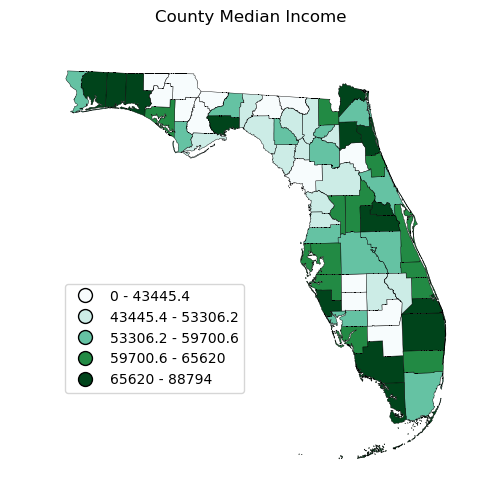

In [17]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import matplotlib.pyplot as plt


gplt.choropleth(
    fl_income, #GeoDataFrame
    hue='Median_income', #color by what value
    cmap='BuGn', linewidth=0.3, #stlyes
    edgecolor='black',
    legend=True,
    scheme = mapclassify.Quantiles(fl_income.Median_income, k=5), #classification from mapclassify
    projection=gcrs.AlbersEqualArea(), #a projection system to map
    
    legend_kwargs={'loc': 'lower left', 'bbox_to_anchor': (0.1, 0.2)}, #other custom parameters for the legend kwargs
    
)
plt.title("County Median Income")
plt.savefig("map_geoplot.png", dpi=300)

## [Legendgram](https://github.com/pysal/legendgram)

In [18]:
#pip install legendgram

(np.float64(-88.00575900329723),
 np.float64(-79.65119941404045),
 np.float64(24.222626877272624),
 np.float64(31.319613444347386))

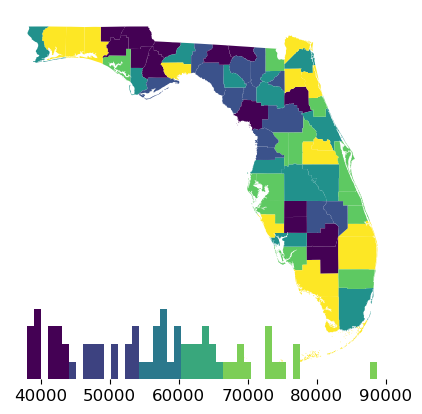

In [19]:
from legendgram import legendgram
import palettable.matplotlib as palmpl

f,ax = plt.subplots()


fl_income.plot('Median_income', k=5, ax=ax, scheme='Quantiles')


#bins returns the steps
bins = mapclassify.Quantiles(fl_income['Median_income'], k=5).bins

legendgram(f,ax,fl_income['Median_income'],bins,pal=palmpl.Viridis_5,
           
          legend_size=(1, 0.2), # legend size in fractions of the axis
           
           loc = 'lower left', # matplotlib-style legend locations
           
           )


ax.axis('off')

## Circle Symbol Map/Bubble Map

Get some data

In [20]:
#pip install us

In [21]:
#pip install census

In [22]:
from census import Census
import us

In [23]:
#Request a key from here: 
"""
https://api.census.gov/data/key_signup.html
"""
census_api_key = "0ed8bfc03db7e7bf1b990114c59b0840650c4fc7" #Replace this with yours

c = Census(census_api_key)

In [24]:
fl_census = c.acs5.state_county(fields = ('NAME', 'B01003_001E'), #variable names
                                      state_fips = '*', #state FIPS code for FL
                                      county_fips = "*", #"*" means all counties in the state
                                      year = 2019) # 2019 data

In [25]:
fl_df = pd.DataFrame(fl_census)
fl_df = fl_df.rename(columns={
    "B01003_001E": "total_population",})

In [26]:
url = us.states.FL.shapefile_urls()['county']
fl_county = gpd.read_file(url)

In [27]:
fl_df["GEOID10"] = fl_df["state"] + fl_df["county"]


fl_county_pop = pd.merge(fl_county, fl_df,on="GEOID10")

In [28]:
fl_county_pop.columns

Index(['STATEFP10', 'COUNTYFP10', 'COUNTYNS10', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'LSAD10', 'CLASSFP10', 'MTFCC10', 'CSAFP10', 'CBSAFP10',
       'METDIVFP10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'geometry', 'NAME', 'total_population', 'state',
       'county'],
      dtype='object')

### **Proportional vs. Graduated:** 

For **proportional symbol maps**, the size of the symbols are in direct relation to the value that is being displayed. **Graduated symbols** use symbol sizes to represent classes of data rather than unique or absolute values.

For Symbol map becuase the symbol needs to be placed at the centroid of each polygon, it is better to project the data first from its lat/long crs.

### Matplotlib's Graduated symbol map

In [29]:
fl_county_pop.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [30]:
fl_county_pop_proj = fl_county_pop.to_crs(epsg=5070)

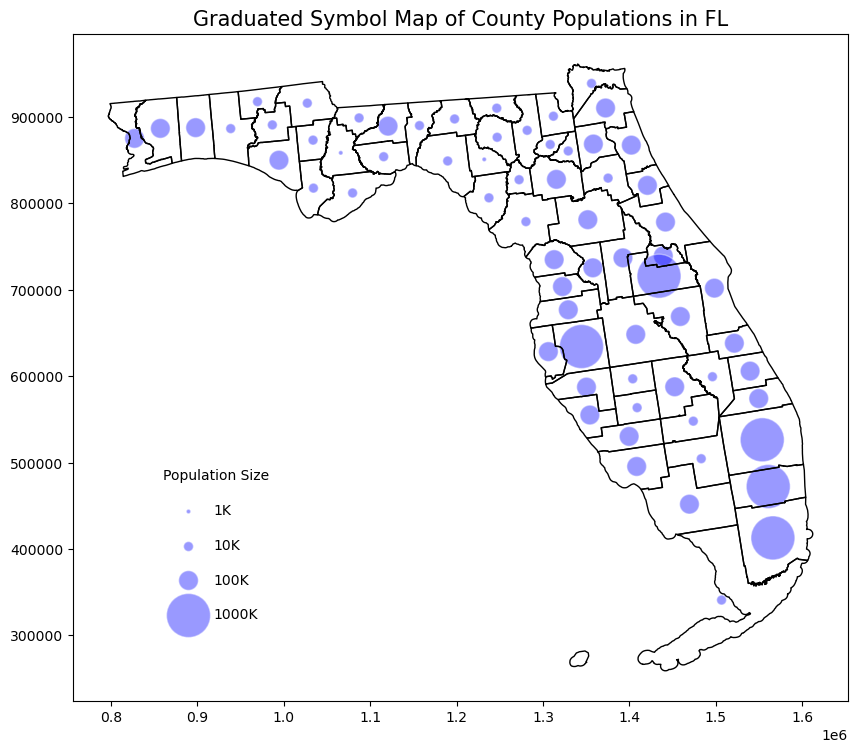

In [31]:
# Plot the base map
fig, ax = plt.subplots(figsize=(10, 10))

fl_county_pop_proj.boundary.plot(ax=ax, linewidth=1,color='black')


ranges = [1000, 10000, 100000, 1000000]

sizes = [10, 50, 200, 1000]


# Function to normalize population size for symbol scaling
def scale_size(pop):
    
    if pop >= ranges[3]:
        return sizes[3]
    elif pop >= ranges[2]:
        return sizes[2]
    elif pop >= ranges[1]:
        return sizes[1]
    else:
        return sizes[0]

    
# Plot circles
fl_county_pop_proj.centroid.plot(
    ax=ax,
    color='blue',
    markersize=fl_county_pop_proj['total_population'].apply(scale_size),
    alpha=0.4,
    edgecolor='white'
)

# Add title
plt.title('Graduated Symbol Map of County Populations in FL', fontsize=15)

# Create a legend with sample population sizes
for pop in ranges:
    plt.scatter([], [], s=scale_size(pop), color='blue', alpha=0.4, edgecolor='white', label=f'{pop//1000}K')

    
plt.legend(scatterpoints=1, frameon=False, labelspacing=1.5, title='Population Size',loc='lower left',
          bbox_to_anchor=(0.1, 0.1))



## GeoPlot's Proportional symbol map

/var/folders/ws/56fpnn4d4wn5c23d593164fr0000gp/T/ipykernel_43128/3591593499.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fl_county_pop_centroids['geometry'] = fl_county_pop_centroids.centroid


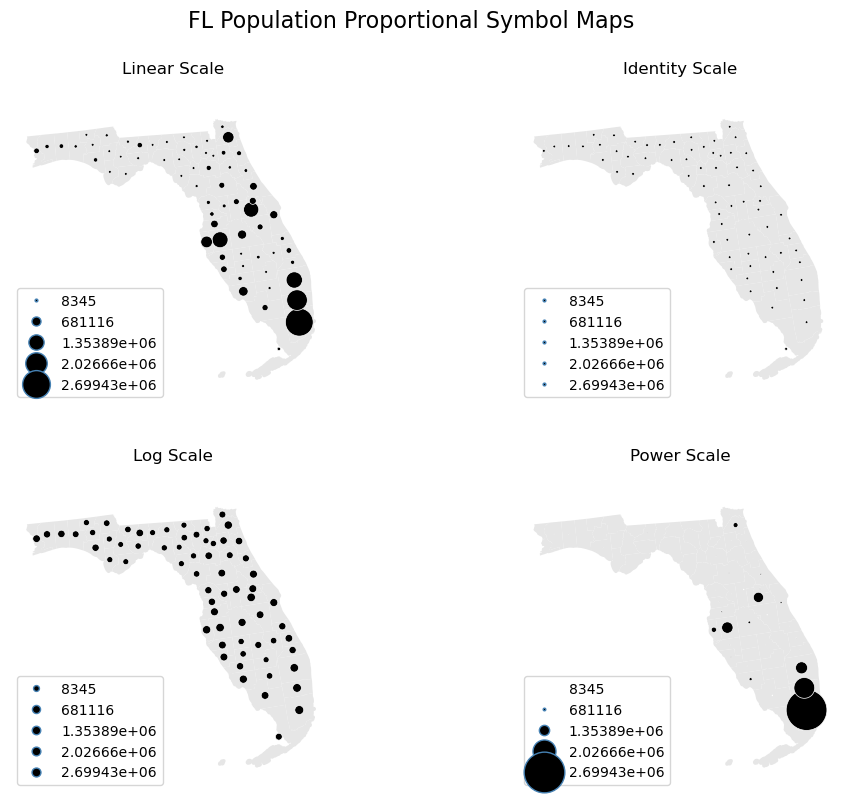

In [32]:
import geoplot as gplt
import geoplot.crs as gcrs


fl_county_pop_centroids = fl_county_pop.copy()
fl_county_pop_centroids['geometry'] = fl_county_pop_centroids.centroid


proj = gcrs.AlbersEqualArea(central_longitude=-98, central_latitude=39.5)


f, axes = plt.subplots(2, 2, figsize=(12, 9), subplot_kw={'projection': proj})


"""
Common Viz parameter for the symbology
"""
polyplot_kwargs = {'facecolor': (0.9, 0.9, 0.9), 'linewidth': 0}

pointplot_kwargs = {
    'scale': 'total_population', 'edgecolor': 'white', 'linewidth': 0.5, 'color': 'black',
    'legend': True
}


"""
Linear
"""

gplt.polyplot(fl_county_pop.geometry, ax=axes[0][0], **polyplot_kwargs)



gplt.pointplot(
    fl_county_pop_centroids,
    ax=axes[0][0], limits=(2, 20), **pointplot_kwargs
)
axes[0][0].set_title("Linear Scale")


"""
Identity
"""


def identity_scale(minval, maxval):
    def scalar(val):
        return 2
    return scalar



gplt.polyplot(fl_county_pop.geometry, ax=axes[0][1], **polyplot_kwargs)
gplt.pointplot(
    fl_county_pop_centroids,
    ax=axes[0][1], scale_func=identity_scale, **pointplot_kwargs
)

axes[0][1].set_title("Identity Scale")

"""
Log
"""

def log_scale(minval, maxval):
    def scalar(val):
        val = val + abs(minval) + 1
        return np.log10(val)
    return scalar



gplt.polyplot(
    fl_county_pop.geometry,
    ax=axes[1][0], **polyplot_kwargs
)
gplt.pointplot(
    fl_county_pop_centroids,
    ax=axes[1][0], scale_func=log_scale, **pointplot_kwargs
)
axes[1][0].set_title("Log Scale")

"""
Power
"""

def power_scale(minval, maxval):
    def scalar(val):
        val = val + abs(minval) + 1
        return (val / 500000)**2
    return scalar

gplt.polyplot(
    fl_county_pop.geometry,
    ax=axes[1][1], **polyplot_kwargs
)
gplt.pointplot(
    fl_county_pop_centroids,
    ax=axes[1][1], scale_func=power_scale, **pointplot_kwargs
)
axes[1][1].set_title("Power Scale")



plt.suptitle('FL Population Proportional Symbol Maps', fontsize=16)

plt.subplots_adjust(top=0.9)

## Kernel Density Heat Map

A Kernel Density Heat Map is a spatial visualization that uses Kernel Density Estimation (KDE) to show where geographic events or observations are concentrated.

Instead of displaying individual points, it creates a smooth, continuous surface representing the estimated density of those points.

In [33]:
shelter = pd.read_csv("https://raw.githubusercontent.com/Ziqi-Li/GIS5103/refs/heads/main/data/Shelter_inventory.csv")

In [34]:
geometry = gpd.points_from_xy(shelter.Long, shelter.Lat)

shelter_gdf = gpd.GeoDataFrame(shelter, geometry=geometry, crs="EPSG:4326")

<Axes: >

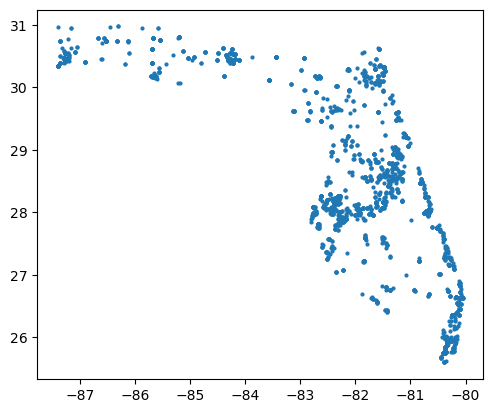

In [35]:
shelter_gdf.plot(markersize=4)

<Axes: xlabel='None', ylabel='None'>

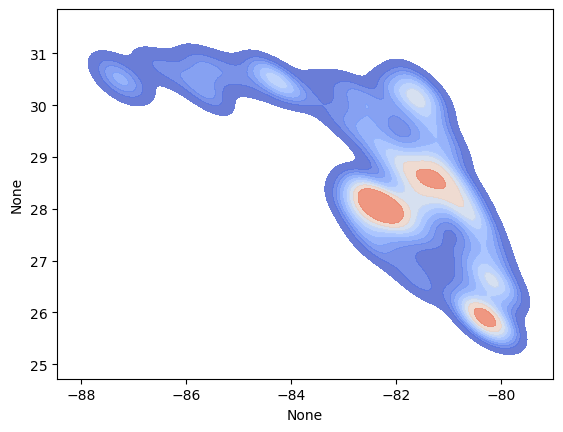

In [36]:
sns.kdeplot(data=shelter_gdf,
            x=shelter_gdf.geometry.x,
            y=shelter_gdf.geometry.y,
            bw_method=0.2, #the bandwidth controls the scale of the heat density
            fill=True,
            cmap="coolwarm",
            alpha=0.8)

## Adding Basemaps

## [Contextily](https://contextily.readthedocs.io/en/latest/)

Check here for the providers: https://leaflet-extras.github.io/leaflet-providers/preview/

In [37]:
import contextily as cx 

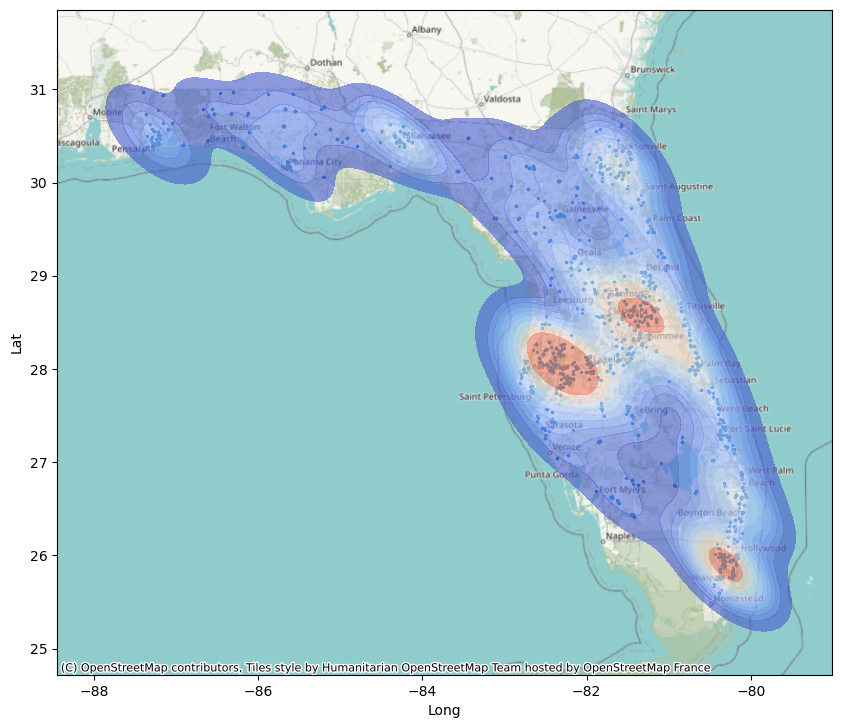

In [38]:
f, ax = plt.subplots(figsize=(10,10)) #Creata a map with size 10 by 10


shelter_gdf.plot(ax=ax, markersize = 2)


sns.kdeplot(ax=ax,data=shelter_gdf, x=shelter_gdf.geometry.x, y=shelter_gdf.geometry.y, bw_method=0.2, fill=True,
            cmap="coolwarm",alpha=0.6)



#This is the new line of code:
#We need to put a crs into the function.
#The source parameter defines the style of the base map: https://contextily.readthedocs.io/en/latest/providers_deepdive.html
#There are many options available.


# Carto recently requries to add an API key to use their basemap.
#cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=shelter_gdf.crs, zoom=7) # we need to put a crs into the function.

#put label on top of heat map
cx.add_basemap(ax, crs=shelter_gdf.crs,zoom=7)
#cx.add_basemap(ax, crs=shelter_gdf.crs,zoom=7) 

ax.set_xlabel("Long")
ax.set_ylabel("Lat")

plt.savefig("clusters.png",dpi=600)

## [Folium](https://python-visualization.github.io/folium/latest/index.html)

In [39]:
#pip install folium

In [40]:
import folium

from folium import plugins

map = folium.Map(location=[28, -84], tiles="OpenStreetMap", zoom_start=7)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in shelter_gdf.geometry]

plugins.HeatMap(heat_data,radius = 10).add_to(map)

map

### Folium Choropoleth Map

In [41]:
#map = folium.Map(location=[28, -84], tiles="CartoDB positron", zoom_start=7)


folium.Choropleth(
    geo_data=fl_income.set_index("COUNTYNAME"),
    name="choropleth layer",
    data=fl_income,
    columns=["COUNTYNAME", "Median_income"],
    key_on="feature.id",
    fill_color="YlGn",
    fill_opacity=0.5,
    line_opacity=0.5,
    legend_name="Median Income ($)",
).add_to(map)

folium.LayerControl().add_to(map)

map

#map.save("fl_map_web.html")

## Plotly [Gallary](https://plotly.com/python/)

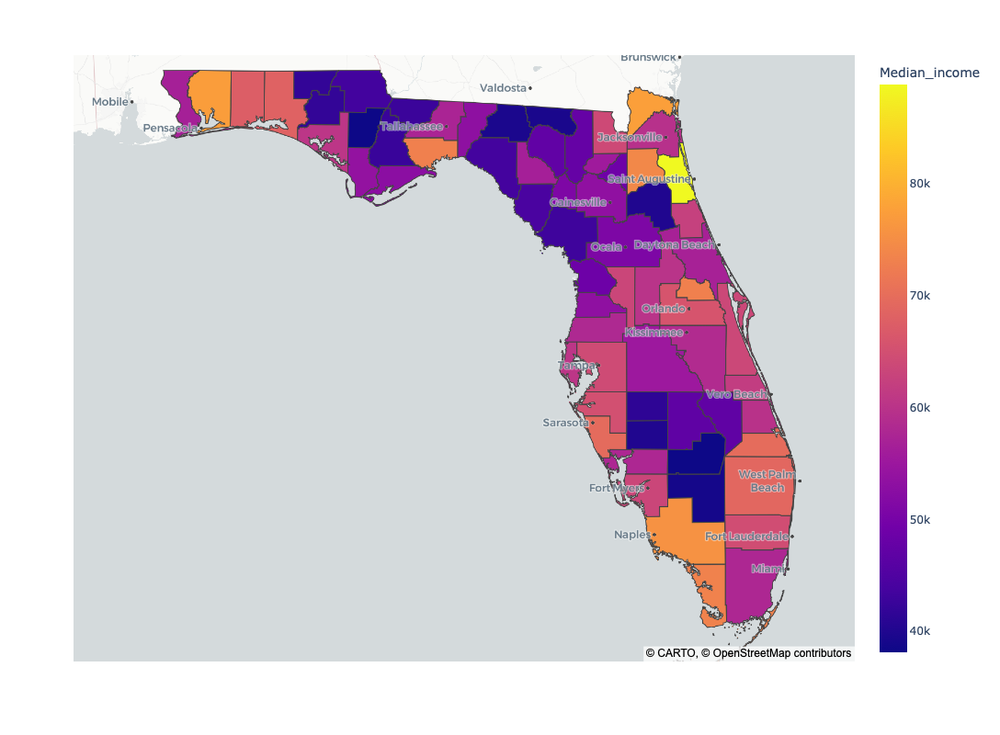

In [42]:
import plotly.express as px


fig = px.choropleth_map(fl_income, 
                           geojson=fl_income.geometry,
                           locations=fl_income.index, 
                           color='Median_income',
                           center={"lat": 28, "lon": -84},
                           map_style="carto-positron",
                           zoom=6, width=1000, height=800)


fig.show()
fig.write_html("fl_income.html")

#pip install kaleido
#fig.write_image("fl_income.png")

## Color suggestions:

If you want to use colors other than provided by `matplotlib`, you can find hex code of the colors and use them instead. Below are some references.

- https://colorbrewer2.org/#type=sequential&scheme=BuGn&n=3
- https://leonardocolor.io/scales.html#
- https://vega.github.io/vega/docs/schemes/#:~:text=Multi%2DHue%20Schemes-,Sequential%20color%20schemes%20can%20be%20used%20to%20encode%20quantitative%20values,for%20visualizations%20such%20as%20heatmaps.

In [43]:
from matplotlib.colors import ListedColormap

hex_color = ['#f0f9e8',
'#bae4bc',
'#7bccc4',
'#43a2ca',
'#0868ac']

#hex_color.reverse()

# Create a custom colormap using ColorBrewer hex codes
cmap = ListedColormap(hex_color)

Text(0.5, 1.0, 'County Median Income')

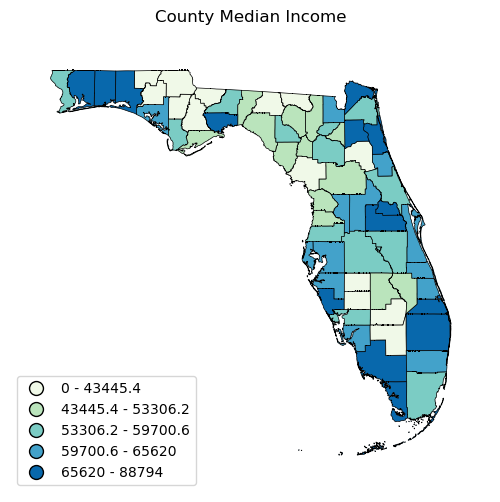

In [44]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import matplotlib.pyplot as plt

gplt.choropleth(
    fl_income,
    hue='Median_income',
    cmap=cmap, linewidth=0.5,
    edgecolor='black',
    legend=True,
    scheme = mapclassify.Quantiles(fl_income.Median_income, k=5),
    projection=gcrs.WebMercator(),
    legend_kwargs={'loc': 'lower left'},
)
plt.title("County Median Income")
